## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual

### Methods

* **MOLA**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo, get_objectives, MooScalarization
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_pareto_3d, plot_multiple_hypervolumes, plot_hypervolume
from ml_moo.scalarization.three_objs_hate_speech import HateSpeechScalarization

In [4]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})

In [7]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [8]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)


In [11]:
from sklearn.decomposition import PCA

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced


In [12]:
from collections import Counter
from torch.utils.data import Dataset

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: np.ndarray, raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        labels = data["annotators"]["label"]
        majority_label = Counter(labels).most_common(1)[0][0]
        label_hate = 0 if majority_label == 1 else 1

        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
       
        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
        }


In [13]:
# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

embeddings = extract_bert_embeddings(dataset["train"])
pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
#
## Agora use para treinar seu modelo
dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)


100%|██████████| 481/481 [00:47<00:00, 10.17it/s]


In [14]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
       
        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long)
        }

In [15]:
# Criar os datasets para treino, validação e teste
#train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#test_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#
## DataLoaders
#batch_size = 8
#train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#valid_dataloader = DataLoader(val_dataset, batch_size=batch_size)
#test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [16]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

## MOLA

93 min 28s - 50 iter

12:05:39 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
12:05:39 | DEBUG | ml_moo | Finding 1th individual minimum


Device: cuda:0 | CUDA available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 119.60it/s]


Epoch 1 - Average training loss: 0.2449


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 123.34it/s]


...

Epoch 2 - Average training loss: 0.1065


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 128.28it/s]


Epoch 3 - Average training loss: 0.1070


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 146.75it/s]
12:12:16 | DEBUG | ml_moo | Calculated weights: [0.         0.50876336 0.49123664]
12:12:16 | DEBUG | ml_moo | Importance: 0.00012088468018672804
12:12:16 | DEBUG | ml_moo | Global lower bound (y*): [0.58890841 0.35029341 0.26563489]
12:12:16 | DEBUG | ml_moo | Iteration 51
12:12:16 | DEBUG | ml_moo | Solutions list: [array([0.58915638, 0.35031779, 0.26615294]), array([0.58907944, 0.35029341, 0.2665255 ]), array([0.58890841, 0.35130044, 0.2659225 ]), array([0.58894444, 0.35081799, 0.26563489]), array([0.58940066, 0.35064753, 0.26586818]), array([0.5895031 , 0.35067126, 0.26583956])]


new solution dominated [0.58921971 0.35038459 0.26630731]


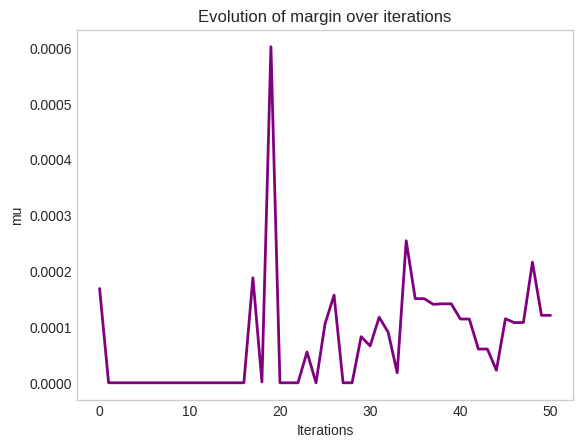

12:12:16 | INFO | ml_moo | Fit runtime: 396.46 seconds


In [17]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [18]:
targets = ["General", "Women", "Homosexual"]

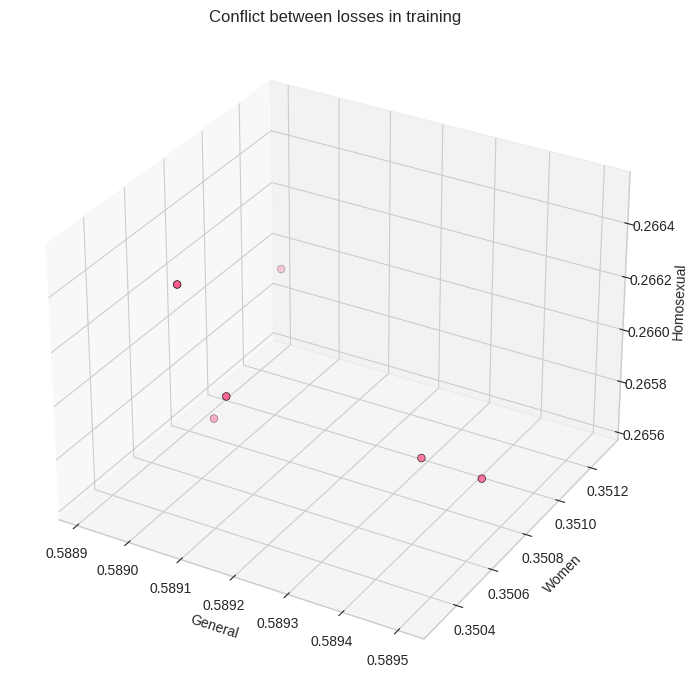

In [19]:
title="Conflict between losses in training"
plot_pareto_3d(objectives=objs, 
               labels=targets,
               title=title,
               color="#FF5C8D"
               )

12:12:16 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
12:12:16 | DEBUG | ml_moo | Finding 1th individual minimum


Device: cuda:0 | CUDA available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 125.76it/s]


Epoch 1 - Average training loss: 0.2300


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 126.28it/s]


...

Epoch 2 - Average training loss: 0.1746


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 128.58it/s]


Epoch 3 - Average training loss: 0.1744


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 142.40it/s]
12:18:50 | DEBUG | ml_moo | Calculated weights: [7.66411904e-01 4.20611324e-10 2.33588096e-01]
12:18:50 | DEBUG | ml_moo | Importance: 7.926553843806694e-05
12:18:50 | DEBUG | ml_moo | Global lower bound (y*): [0.58874616 0.35023395 0.26566903]
12:18:50 | DEBUG | ml_moo | Iteration 51
12:18:50 | DEBUG | ml_moo | Solutions list: [array([0.58910166, 0.35092059, 0.26579972]), array([0.58929711, 0.35084956, 0.26566903]), array([0.58905932, 0.35046119, 0.26609031]), array([0.58874616, 0.35077109, 0.26696613]), array([0.5891298 , 0.35023395, 0.2666772 ]), array([0.58900063, 0.35101816, 0.26650034]), array([0.58964327, 0.35043669, 0.26664292])]


new solution added [0.58910166 0.35092059 0.26579972]


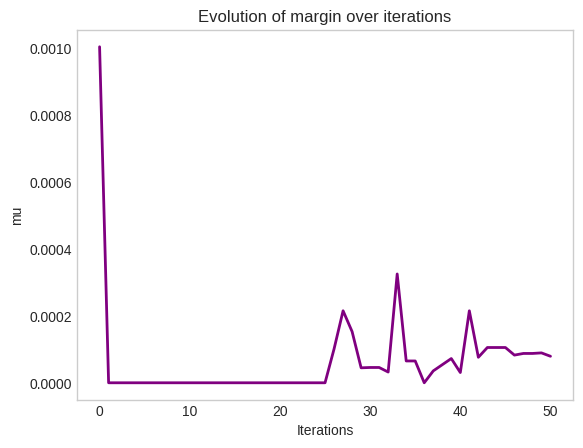

12:18:50 | INFO | ml_moo | Fit runtime: 393.97 seconds


In [20]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name, gradient=True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

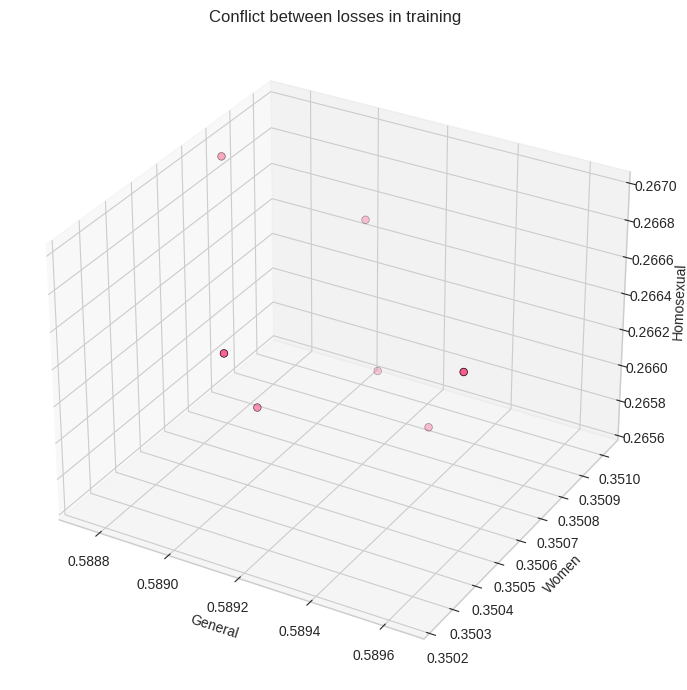

In [21]:
title="Conflict between losses in training"
plot_pareto_3d(objectives=objs, 
               labels=targets,
               title=title,
               color="#FF5C8D"
               )

## Random Weight

+ 154

In [ ]:
method = 'random_weight'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

12:18:51 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
12:18:51 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
12:18:51 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


Device: cuda:0 | CUDA available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 127.36it/s]


Epoch 1 - Average training loss: 0.2241


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 129.69it/s]


...

Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 126.57it/s]


Epoch 2 - Average training loss: 0.1178


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 122.78it/s]


Epoch 3 - Average training loss: 0.1171


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 151.77it/s]
12:55:29 | DEBUG | ml_moo.moo.random_weights | 300th solution


## Comparison between MOO methods

In [23]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

12:55:30 | WARNING | ml_moo | [Methods have different numbers of solutions: {300, 6, 7}


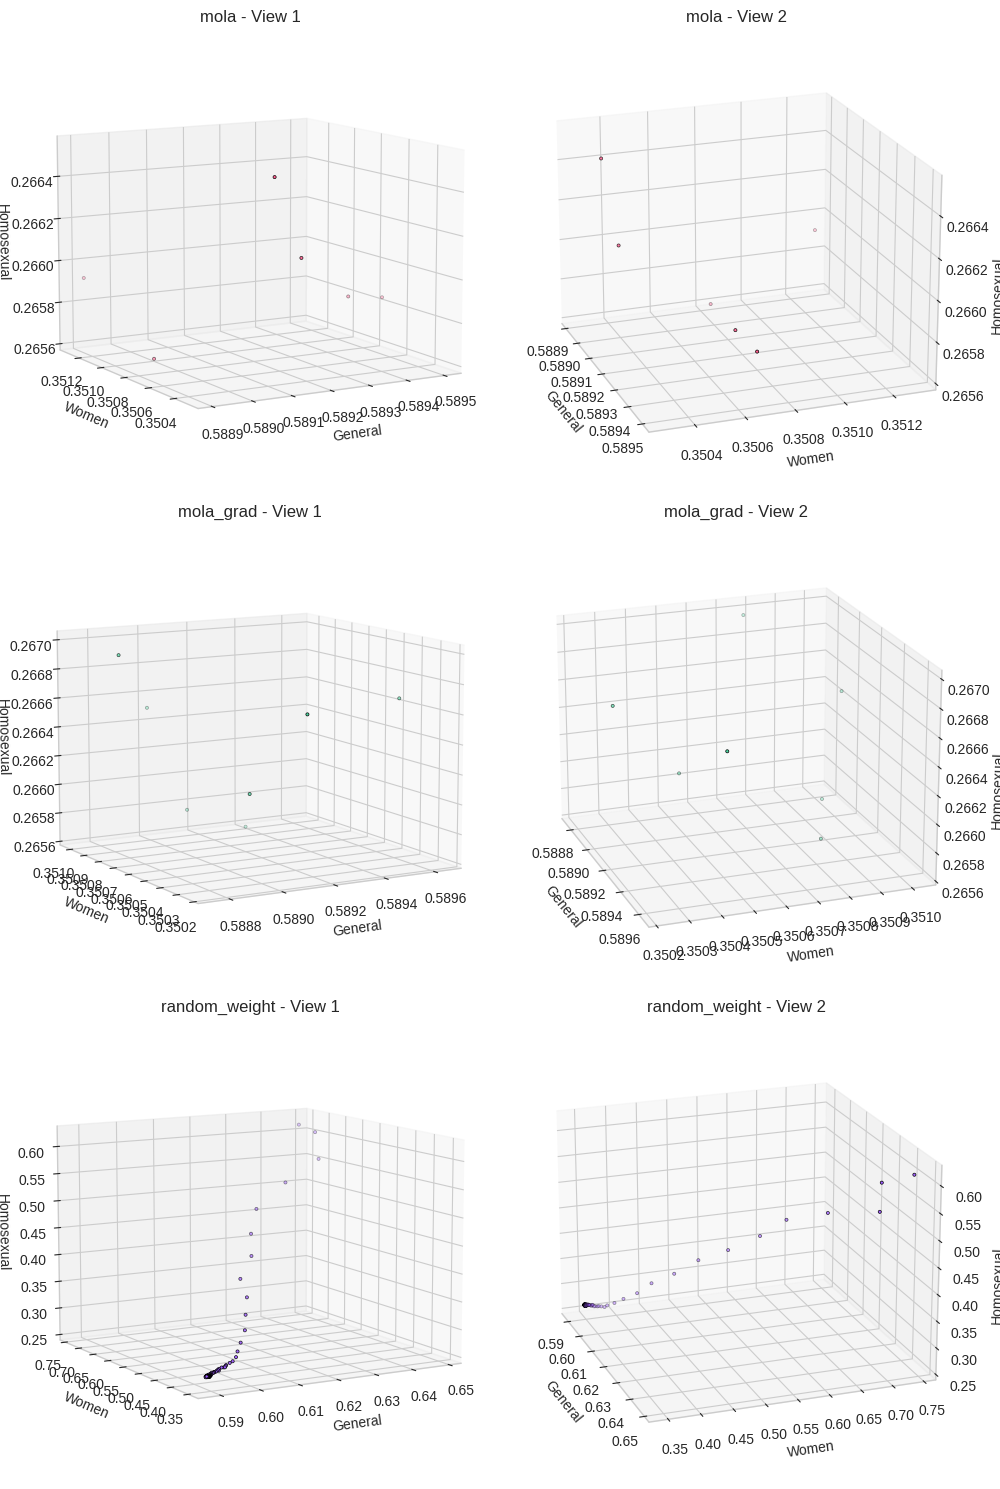

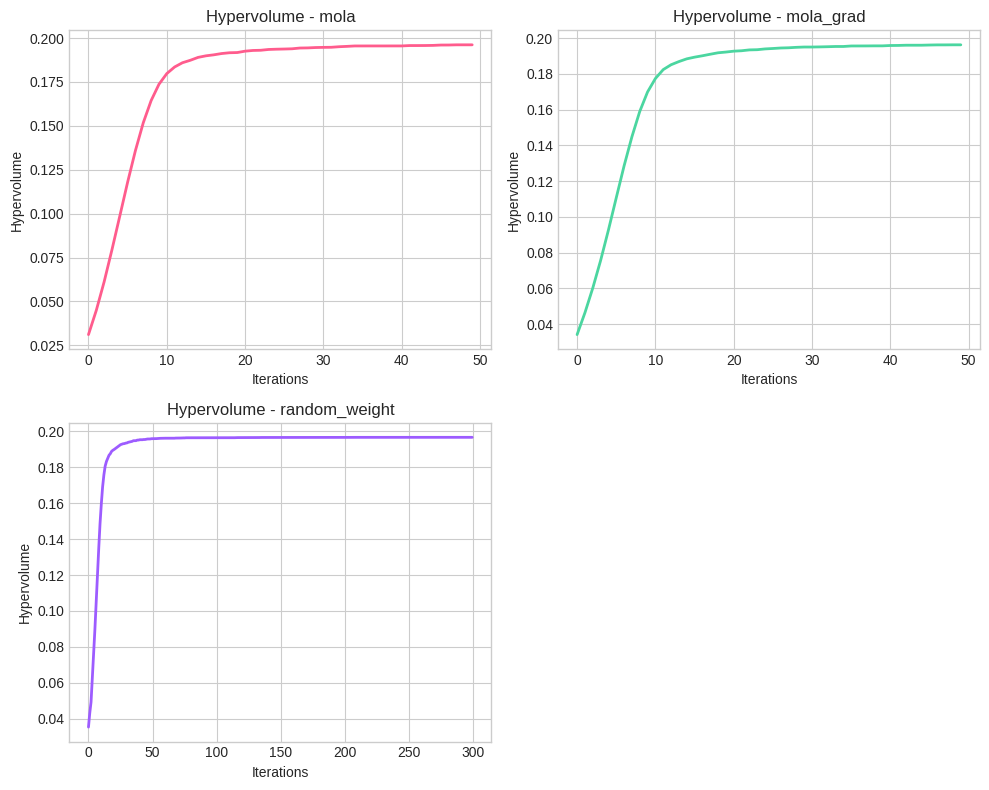

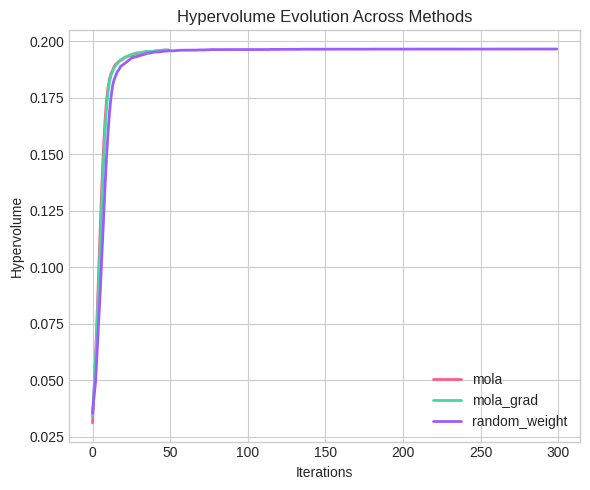

[Analyzer] Visualization complete.


In [24]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = targets

Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [25]:
from ml_moo.analysis.visualization import plot_pareto_3d_set_limit

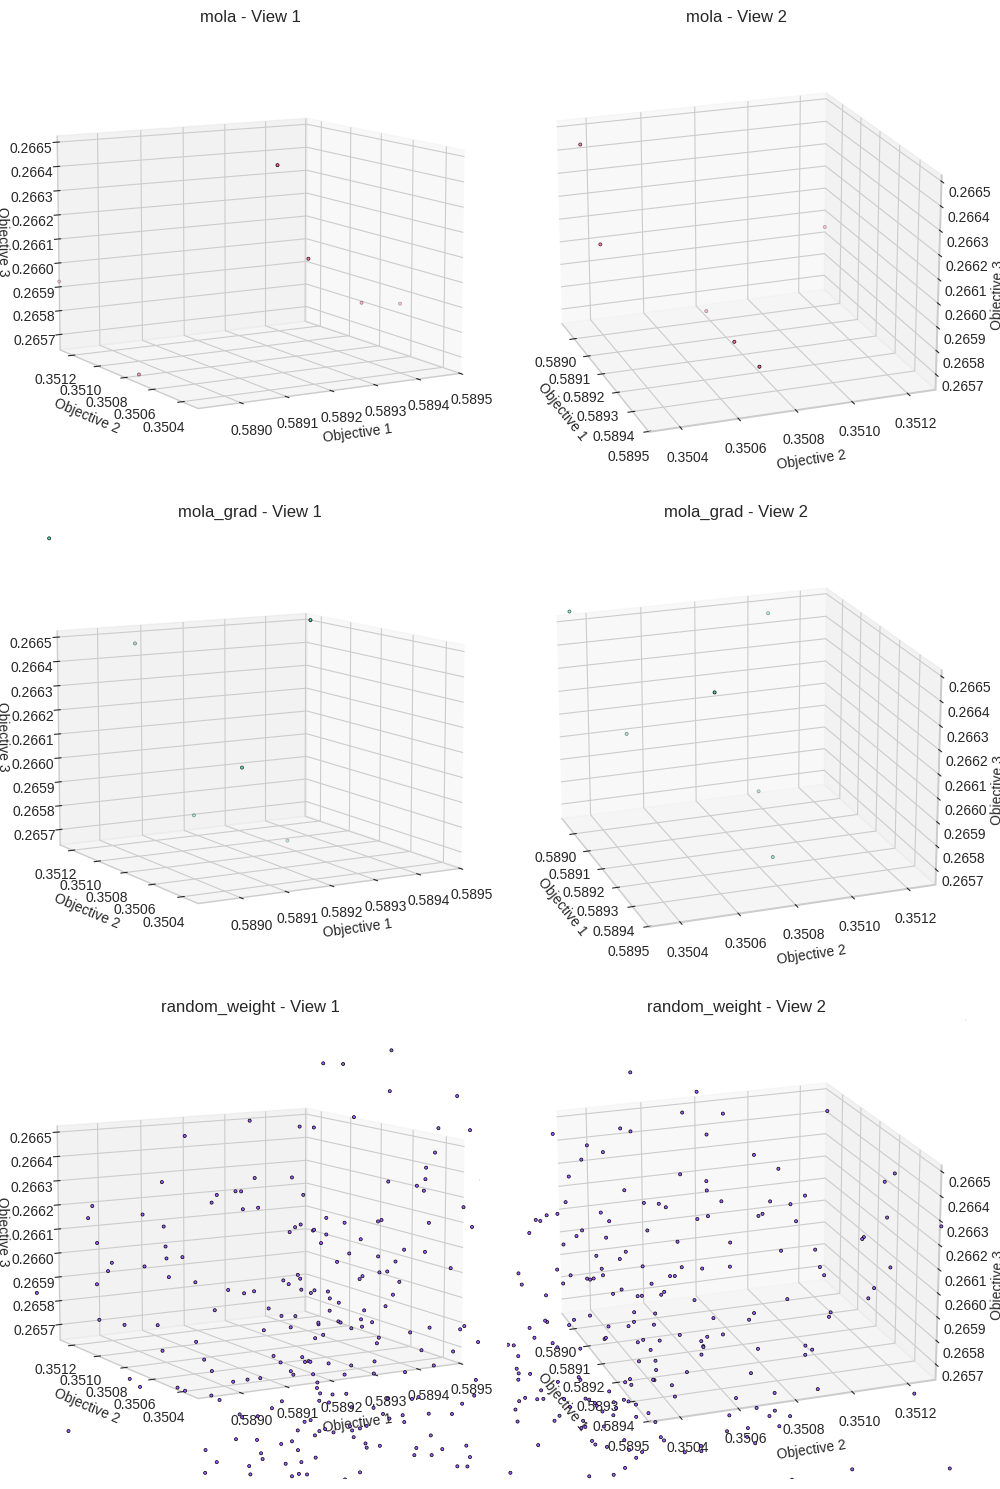

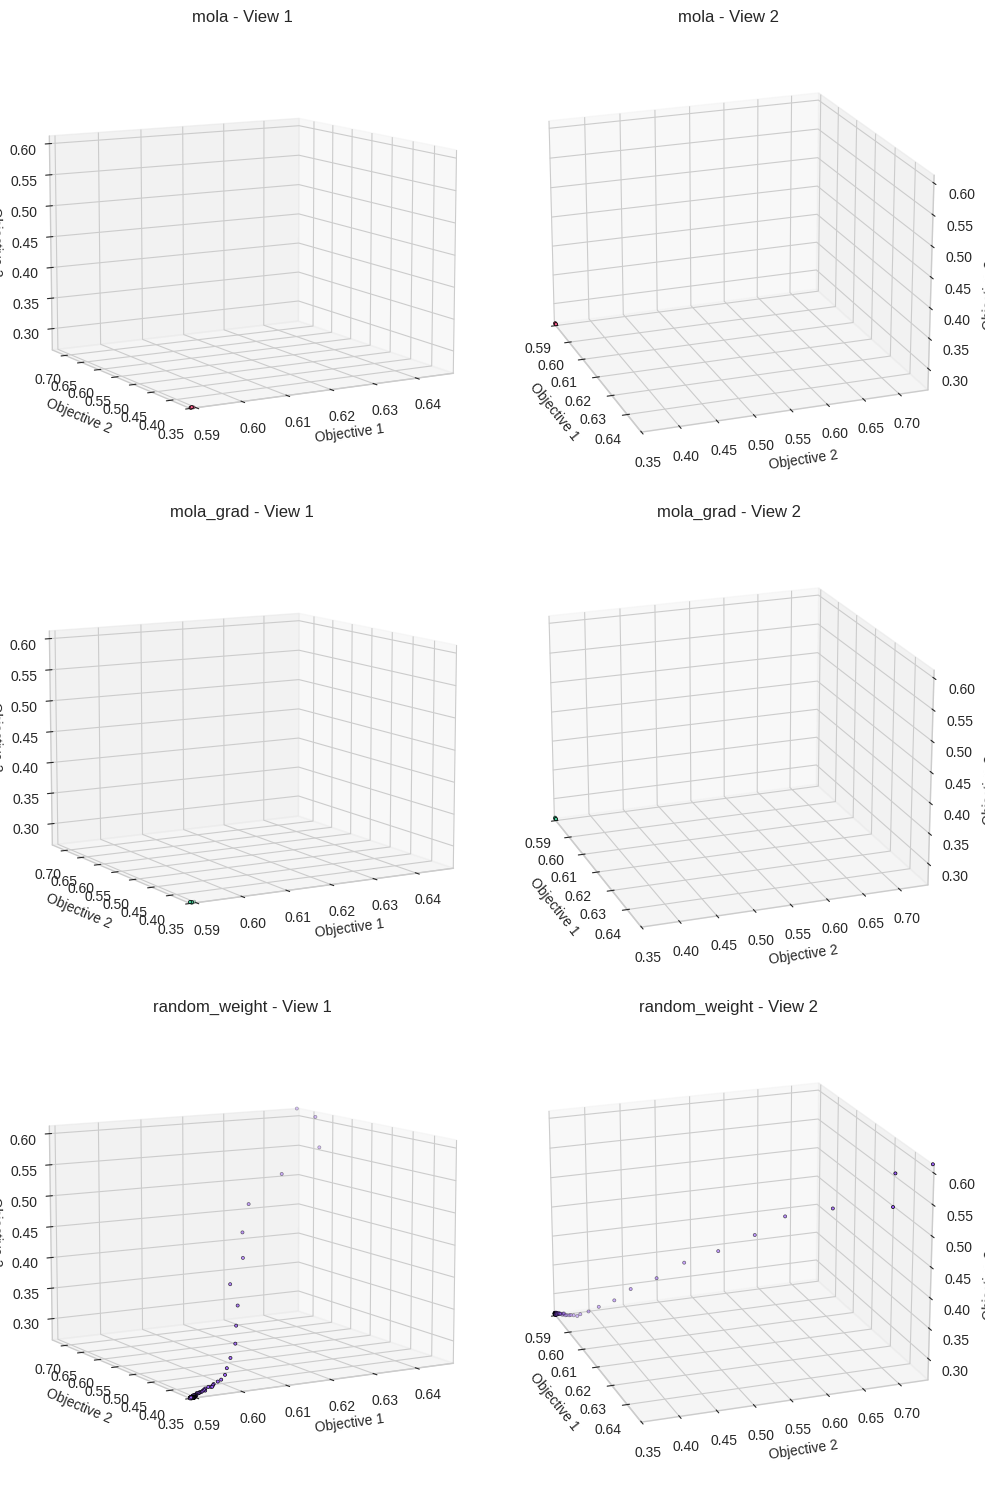

: 

In [ ]:
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 